# SHAR Model on the MHAR Feature Set


**Purpose:** The purpose of this notebook is to compute the out-of-sample forecast performance of the SHAR model on the $\mathcal{M}_{\mathrm{HAR}}$ feature set for the EURO STOXX 50 index. Following the same benchmark workflow as the HAR and LogHAR notebooks, we estimate the model on a rolling window and evaluate one-day-ahead forecasts using the Mean Squared Error (MSE). The model is estimated in realized-variance levels using positive and negative semivariance together with the standard weekly and monthly MHAR components, and all reported results are kept in levels format for direct comparison with the other benchmark models.


## 1.1 Loading Data


In [1]:
import pandas as pd
import numpy as np

# Load MALL dataset
file_path = "/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/Cleaned Data/MALL.csv"
MALL = pd.read_csv(file_path, index_col='Date', parse_dates=True)

print(f"Shape: {MALL.shape}")
print(f"Date range: {MALL.index[0].date()} to {MALL.index[-1].date()}")
print(f"NaN values: {MALL.isna().sum().sum()}")
MALL.head()


Shape: (5489, 31)
Date range: 1999-01-05 to 2020-08-06
NaN values: 0


,RVD,RVW,RVM,logRVD,logRVW,logRVM,RVD_pos,RVD_neg,RD_neg,RW_neg,...,BRENT,BRENT_ret,NIKKEI_ret,NIKKEI_sq,SP500_ret_lag,SP500_sq_lag,M1W,M1M,RV_target,logRV_target
Date,,,,,,,,,,,,,,,,,,,,,
1999-01-05,0.000078,0.000093,0.000129,-9.462355,-9.288024,-8.958306,0.000046,0.000032,0.000000,-0.000682,...,10.30,-0.060282,-0.013746,0.000189,-0.000920,8.458434e-07,0.087690,0.126206,0.000058,-9.760055
1999-01-06,0.000058,0.000092,0.000123,-9.760055,-9.290171,-9.005038,0.000043,0.000014,0.000000,-0.000682,...,10.67,0.035292,0.017657,0.000312,0.013491,1.819949e-04,0.100143,0.187219,0.000139,-8.877543
1999-01-07,0.000139,0.000102,0.000121,-8.877543,-9.192627,-9.023153,0.000072,0.000068,-0.015530,-0.003788,...,11.08,0.037706,0.005044,0.000025,0.021899,4.795626e-04,0.078881,0.184020,0.000108,-9.130603
1999-01-08,0.000108,0.000106,0.000112,-9.130603,-9.148418,-9.097084,0.000055,0.000053,-0.003409,-0.003788,...,11.70,0.054447,-0.010751,0.000116,-0.002053,4.216638e-06,0.078883,0.165510,0.000166,-8.702667
1999-01-11,0.000166,0.000110,0.000110,-8.702667,-9.116188,-9.115384,0.000076,0.000090,-0.019561,-0.007700,...,12.07,0.031134,-0.001744,0.000003,0.004212,1.774503e-05,0.001055,0.140613,0.000115,-9.067553


## 2. Data Split


Following Christensen et al. (2023), we split the sample into a training set (70%), validation set (10%), and test set (20%) in chronological order. The rolling estimation window used for out-of-sample forecasting is the combined training and validation sample, matching the HAR benchmark notebook.


In [2]:
# Train / Validation / Test split (70 / 10 / 20)
n = len(MALL)
n_train = int(np.floor(0.70 * n))
n_val   = int(np.floor(0.10 * n))
n_test  = n - n_train - n_val

train_idx = MALL.index[:n_train]
val_idx   = MALL.index[n_train:n_train + n_val]
test_idx  = MALL.index[n_train + n_val:]

print(f"Total observations: {n}")
print(f"\nTrain:      {train_idx[0].date()} to {train_idx[-1].date()} ({n_train} obs, {n_train/n*100:.1f}%)")
print(f"Validation: {val_idx[0].date()} to {val_idx[-1].date()} ({n_val} obs, {n_val/n*100:.1f}%)")
print(f"Test:       {test_idx[0].date()} to {test_idx[-1].date()} ({n_test} obs, {n_test/n*100:.1f}%)")


Total observations: 5489

Train:      1999-01-05 to 2014-02-26 (3842 obs, 70.0%)
Validation: 2014-02-27 to 2016-04-20 (548 obs, 10.0%)
Test:       2016-04-21 to 2020-08-06 (1099 obs, 20.0%)


## 3. SHAR Model


The SHAR benchmark decomposes the daily realized variance term into positive and negative semivariance:

$$RV_{t+1} = \beta_0 + \beta^{+} RVD^{+}_t + \beta^{-} RVD^{-}_t + \beta_w \overline{RV}^{(w)}_t + \beta_m \overline{RV}^{(m)}_t + \varepsilon_{t+1}$$

where `RVD_pos` and `RVD_neg` capture the positive and negative daily semivariance components, while `RVW` and `RVM` preserve the medium- and long-horizon persistence terms from the HAR benchmark.


### 3.2 Feature Set Construction


In [3]:
# Define target and feature set for SHAR on MHAR
y = MALL["RV_target"]
X_MHAR = MALL[["RVD_pos", "RVD_neg", "RVW", "RVM"]]

print("Target variable: RV_target")
print(f"Predictors: {X_MHAR.columns.tolist()}")
print(f"\nFirst few rows:")
print(pd.concat([y, X_MHAR], axis=1).head())


Target variable: RV_target
Predictors: ['RVD_pos', 'RVD_neg', 'RVW', 'RVM']

First few rows:
            RV_target   RVD_pos   RVD_neg       RVW       RVM
Date                                                         
1999-01-05   0.000058  0.000046  0.000032  0.000093  0.000129
1999-01-06   0.000139  0.000043  0.000014  0.000092  0.000123
1999-01-07   0.000108  0.000072  0.000068  0.000102  0.000121
1999-01-08   0.000166  0.000055  0.000053  0.000106  0.000112
1999-01-11   0.000115  0.000076  0.000090  0.000110  0.000110


### 3.3 Rolling Window Estimation and Forecasting


In [4]:
from sklearn.linear_model import LinearRegression

# Rolling window length = train + validation
window = n_train + n_val

forecasts_SHAR = []
dates_test = []

for i in range(n_test):
    # Extract rolling window
    X_window = X_MHAR.iloc[i : i + window].values
    y_window = y.iloc[i : i + window].values

    # OLS estimation in levels
    model = LinearRegression()
    model.fit(X_window, y_window)

    # One-step-ahead forecast using time t predictors
    X_forecast = X_MHAR.iloc[i + window].values.reshape(1, -1)
    forecast = model.predict(X_forecast)[0]

    # Insanity filter: replace negative forecasts with minimum in-sample RV
    min_rv = y_window.min()
    forecast = max(forecast, min_rv)

    forecasts_SHAR.append(forecast)
    dates_test.append(MALL.index[i + window])

print(f"Forecasts generated: {len(forecasts_SHAR)}")
print(f"Forecast period: {dates_test[0].date()} to {dates_test[-1].date()}")


Forecasts generated: 1099
Forecast period: 2016-04-21 to 2020-08-06


### 3.4 Out-of-Sample Performance Evaluation


Following Christensen et al. (2023), out-of-sample forecast accuracy is evaluated using the Mean Squared Error (MSE). SHAR forecasts and realized values are both compared in realized-variance levels so that the output remains directly comparable to HAR and LogHAR.


In [5]:
# Collect results
results_SHAR = pd.DataFrame({
    "RV_actual": y.loc[dates_test].values,
    "RV_forecast": forecasts_SHAR
}, index=dates_test)

# Compute out-of-sample MSE
mse_SHAR = np.mean((results_SHAR["RV_actual"] - results_SHAR["RV_forecast"])**2)

print(f"Out-of-sample MSE (SHAR): {mse_SHAR:.6e}")
print(f"\nFirst few forecasts vs actuals:")
print(results_SHAR.head(10).to_string())


Out-of-sample MSE (SHAR): 2.238490e-08

First few forecasts vs actuals:
            RV_actual  RV_forecast
2016-04-21   0.000068     0.000133
2016-04-22   0.000079     0.000111
2016-04-25   0.000080     0.000100
2016-04-26   0.000045     0.000100
2016-04-27   0.000157     0.000085
2016-04-28   0.000219     0.000133
2016-04-29   0.000087     0.000171
2016-05-02   0.000107     0.000115
2016-05-03   0.000109     0.000123
2016-05-04   0.000100     0.000128


### 3.4.1 Save Forecasts


In [6]:
import os

# Save SHAR forecasts to CSV for comparison with other models
forecast_path = "/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/Cleaned Data/Forcasts/MHAR"
os.makedirs(forecast_path, exist_ok=True)

# Save forecasts
results_SHAR.to_csv(os.path.join(forecast_path, "forecasts_SHAR.csv"))

# Save MSE summary
mse_summary_SHAR = pd.DataFrame({
    "Model": ["SHAR"],
    "MSE":   [mse_SHAR],
    "RMSE":  [np.sqrt(mse_SHAR)],
    "MAE":   [np.mean(np.abs(results_SHAR["RV_actual"] - results_SHAR["RV_forecast"]))],
    "Mean_Error": [np.mean(results_SHAR["RV_actual"] - results_SHAR["RV_forecast"])],
}).set_index("Model")

mse_summary_SHAR.to_csv(os.path.join(forecast_path, "mse_summary_SHAR.csv"))

print(f"Forecasts saved to: {forecast_path}")
print(f"Files saved:")
print(f"  - forecasts_SHAR.csv ({len(results_SHAR)} rows)")
print(f"  - mse_summary_SHAR.csv")
print(f"\nSHAR MSE: {mse_SHAR:.6e}")


Forecasts saved to: /Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/Cleaned Data/Forcasts/MHAR
Files saved:
  - forecasts_SHAR.csv (1099 rows)
  - mse_summary_SHAR.csv

SHAR MSE: 2.238490e-08


## 4. Results


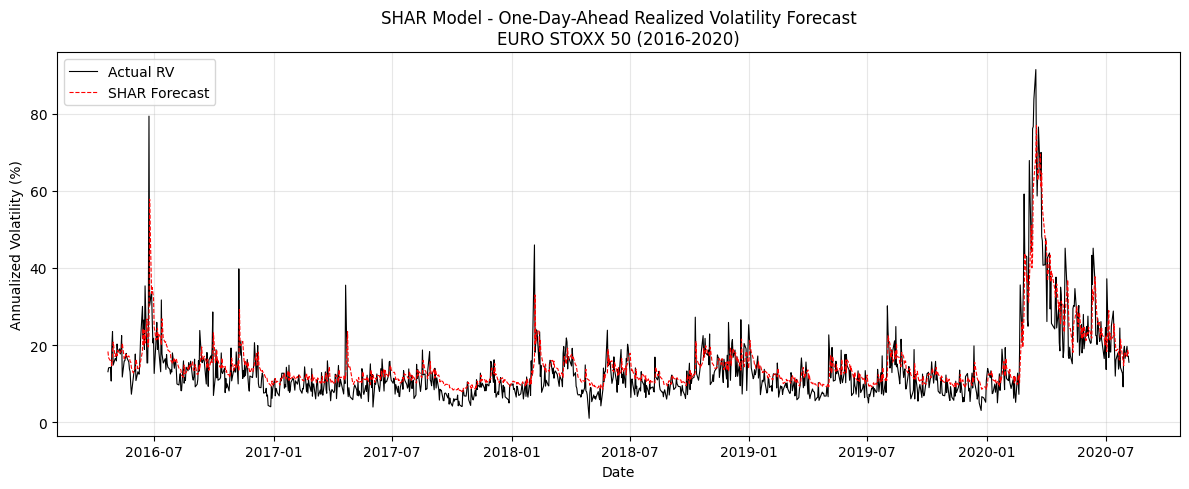


Summary of forecast errors:
Mean error:  -4.216800e-06
RMSE:        1.496159e-04
MAE:         5.594880e-05


In [7]:
import matplotlib.pyplot as plt

# Convert to annualized volatility for readability
results_plot = pd.DataFrame({
    "Actual": np.sqrt(results_SHAR["RV_actual"] * 252) * 100,
    "Forecast": np.sqrt(results_SHAR["RV_forecast"] * 252) * 100
}, index=results_SHAR.index)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(results_plot["Actual"], label="Actual RV", color="black", linewidth=0.8)
ax.plot(results_plot["Forecast"], label="SHAR Forecast", color="red", linewidth=0.8, linestyle="--")
ax.set_title("SHAR Model - One-Day-Ahead Realized Volatility Forecast\nEURO STOXX 50 (2016-2020)", fontsize=12)
ax.set_ylabel("Annualized Volatility (%)")
ax.set_xlabel("Date")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nSummary of forecast errors:")
errors = results_SHAR["RV_actual"] - results_SHAR["RV_forecast"]
print(f"Mean error:  {errors.mean():.6e}")
print(f"RMSE:        {np.sqrt(mse_SHAR):.6e}")
print(f"MAE:         {errors.abs().mean():.6e}")


### 4.2 Forecast Performance Summary


In [8]:
from IPython.display import display

# Summary table of forecast performance
performance = pd.DataFrame({
    "Model": ["SHAR"],
    "MSE":   [mse_SHAR],
    "RMSE":  [np.sqrt(mse_SHAR)],
    "MAE":   [errors.abs().mean()],
    "Mean Error": [errors.mean()],
    "Relative MSE": [1.0]
}).set_index("Model")

styled_performance = (
    performance.style
    .set_caption(
        "Table 3: Out-of-Sample Forecast Performance - SHAR Model\n"
        f"EURO STOXX 50 Test Period: {dates_test[0].date()} to {dates_test[-1].date()} ({n_test} observations)"
    )
    .format({
        "MSE":         "{:.6e}",
        "RMSE":        "{:.6e}",
        "MAE":         "{:.6e}",
        "Mean Error":  "{:.6e}",
        "Relative MSE": "{:.4f}"
    })
    .set_table_styles([
        {"selector": "caption",
         "props": [
             ("font-size", "12px"),
             ("font-weight", "bold"),
             ("text-align", "left"),
             ("padding-bottom", "8px"),
             ("color", "black"),
             ("caption-side", "top"),
         ]},
        {"selector": "thead tr th",
         "props": [
             ("background-color", "white"),
             ("color", "black"),
             ("font-size", "11px"),
             ("text-align", "center"),
             ("padding", "6px 10px"),
             ("border-top", "2px solid black"),
             ("border-bottom", "1px solid black"),
             ("font-weight", "bold"),
         ]},
        {"selector": "tbody tr th",
         "props": [
             ("font-size", "11px"),
             ("font-weight", "bold"),
             ("text-align", "left"),
             ("padding", "4px 10px"),
             ("color", "black"),
             ("background-color", "white"),
             ("border-right", "1px solid black"),
         ]},
        {"selector": "tbody tr td",
         "props": [
             ("font-size", "11px"),
             ("text-align", "right"),
             ("padding", "4px 10px"),
             ("background-color", "white"),
             ("color", "black"),
         ]},
        {"selector": "tbody tr:last-child td, tbody tr:last-child th",
         "props": [("border-bottom", "2px solid black")]},
        {"selector": "table",
         "props": [
             ("border-collapse", "collapse"),
             ("width", "100%"),
         ]},
        {"selector": "td, th",
         "props": [
             ("border-left", "none"),
             ("border-right", "none"),
         ]},
    ])
)

display(styled_performance)


,MSE,RMSE,MAE,Mean Error,Relative MSE
Model,,,,,
SHAR,2.238490e-08,1.496159e-04,5.594880e-05,-4.216800e-06,1.0000
